# Subsurface Oxygen $O_2$

```{glue:figure} average_map
:scale: 50%
:align: center
```

```{glue:figure} average_timeseries
:scale: 50%
:align: center
```

**Figure. Change in Subsurface Oxygen from hindcast.**  The map (top) shows the change in subsurface oxygen concentration (µmol/L) in the vicinity of Palau over the period 1993-2022. The grey line is the Palau EEZ.  The line plot (bottom) shows the change in subsurface oxygen concentration (µmol/L) averaged over the area within the top plot.  The black line represents the trend, which is statistically significant (p < 0.05). The colored dots represent the 10 years with the lowest O2  on record.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import os.path as op
import sys

import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from myst_nb import glue 

sys.path.append("../../../../indicators_setup")

from ind_setup.plotting_int import plot_timeseries_interactive, plot_oni_index_th
from ind_setup.plotting import plot_base_map, plot_map_subplots, add_oni_cat, plot_bar_probs, fontsize

sys.path.append("../../../functions")
from data_downloaders import download_oni_index
from ocean import process_trend_with_nan

## Setup

Define area of interest

In [2]:
#Area of interest
lon_range  = [129.4088, 137.0541]
lat_range = [1.5214, 11.6587]

EEZ shapefile

In [3]:
path_figs = "../../../matrix_cc/figures"

In [4]:
shp_f = op.join(os.getcwd(), '..', '..','..', 'data/Palau_EEZ/pw_eez_pol_april2022.shp')
shp_eez = gpd.read_file(shp_f)

### Load Data

Superficial depth

In [5]:
data_xr = xr.open_dataset(op.join(os.getcwd(), '..', '..','..', 'data/data_phyc_o2_ph.nc'))#.isel(depth = 0).drop('depth')
dataset_id = 'o2'
label = 'O2 [µmol/l]'

## Analysis

### Plotting

#### Average

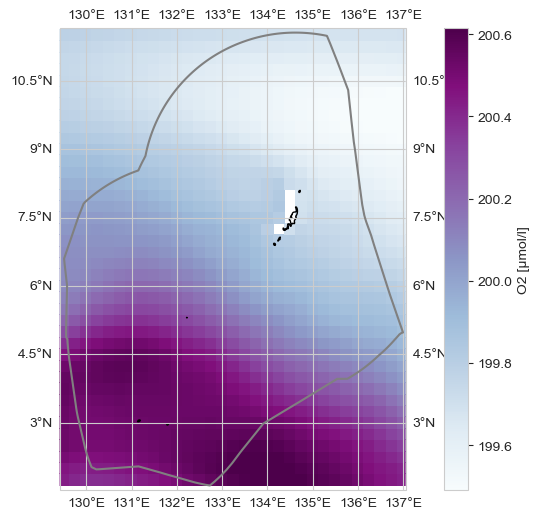

In [6]:
fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
im = ax.pcolor(data_xr.longitude, data_xr.latitude, data_xr.mean(dim='time')[dataset_id], transform=ccrs.PlateCarree(), 
                cmap = 'BuPu', 
                vmin = np.nanpercentile(data_xr.mean(dim = 'time')[dataset_id], 1), 
                vmax = np.nanpercentile(data_xr.mean(dim = 'time')[dataset_id], 99))
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label= label)
glue("average_map", fig, display=False)
plt.savefig(op.join(path_figs, 'F17_O2_mean_map.png'), dpi=300, bbox_inches='tight')


#### Change

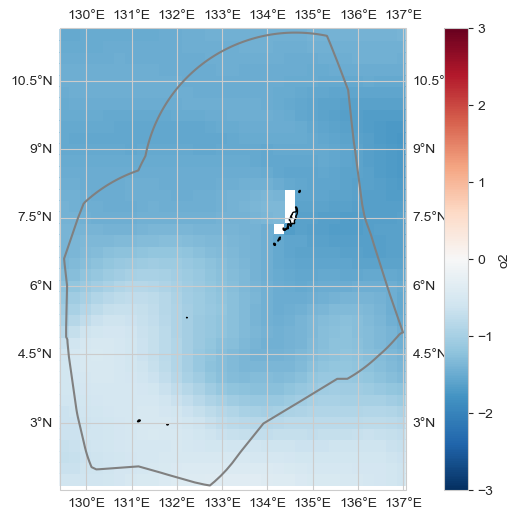

In [8]:
trend_m, _, _, _, _ = process_trend_with_nan(data_xr[dataset_id])

fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
im = ax.pcolor(data_xr.longitude, data_xr.latitude, 
               trend_m,
                transform=ccrs.PlateCarree(), 
                cmap = 'RdBu_r', 
                vmin = -3,
                vmax = 3,
                )
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label=  dataset_id)
plt.savefig(op.join(path_figs, 'F17_O2_mean_map_trend.png'), dpi=300, bbox_inches='tight')


#### Seasonal average

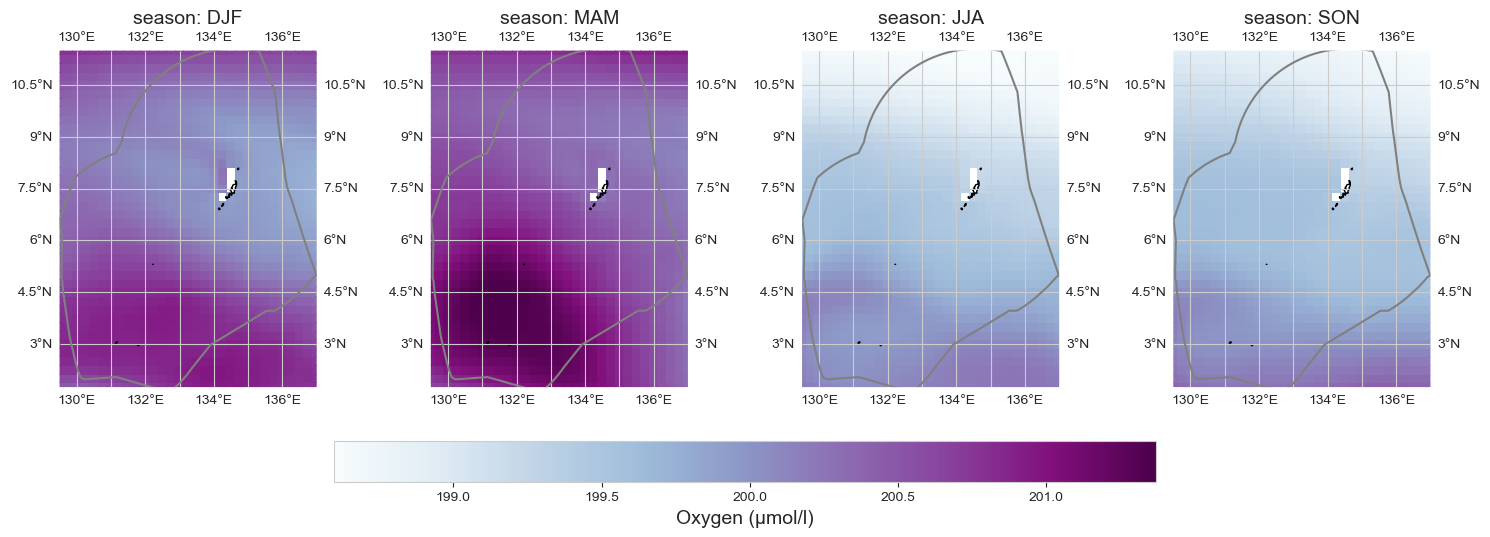

In [8]:
data_month = data_xr.groupby('time.season').mean().sel(season = ['DJF', 'MAM', 'JJA', 'SON'])
im = plot_map_subplots(data_month, dataset_id, shp_eez = shp_eez, cmap = 'BuPu', 
                  vmin = np.nanpercentile(data_month.min(dim = 'season')[dataset_id], 1), 
                  vmax = np.nanpercentile(data_month.max(dim = 'season')[dataset_id], 99),
                  figsize = (15,11), sub_plot = [1, 4], cbar_pad = 0.05, cbar = 1)

#### Seasonal anomaly

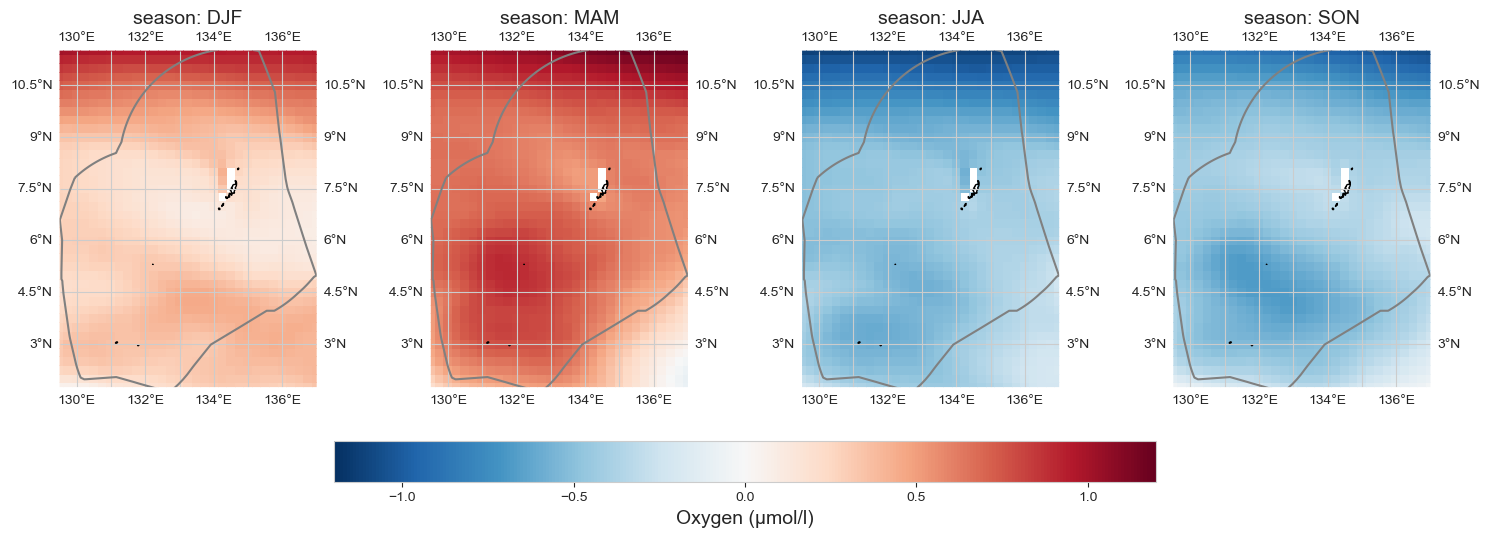

In [9]:
data_month = data_xr.groupby('time.season').mean().sel(season = ['DJF', 'MAM', 'JJA', 'SON']) - data_xr.mean(dim='time')
im = plot_map_subplots(data_month, dataset_id, shp_eez = shp_eez, 
                  cmap = 'RdBu_r', vmin=-1.2, vmax=1.2,
                  figsize = (15,11), sub_plot = [1, 4], cbar_pad = 0.05,
                  cbar = 1)

#### Annual average

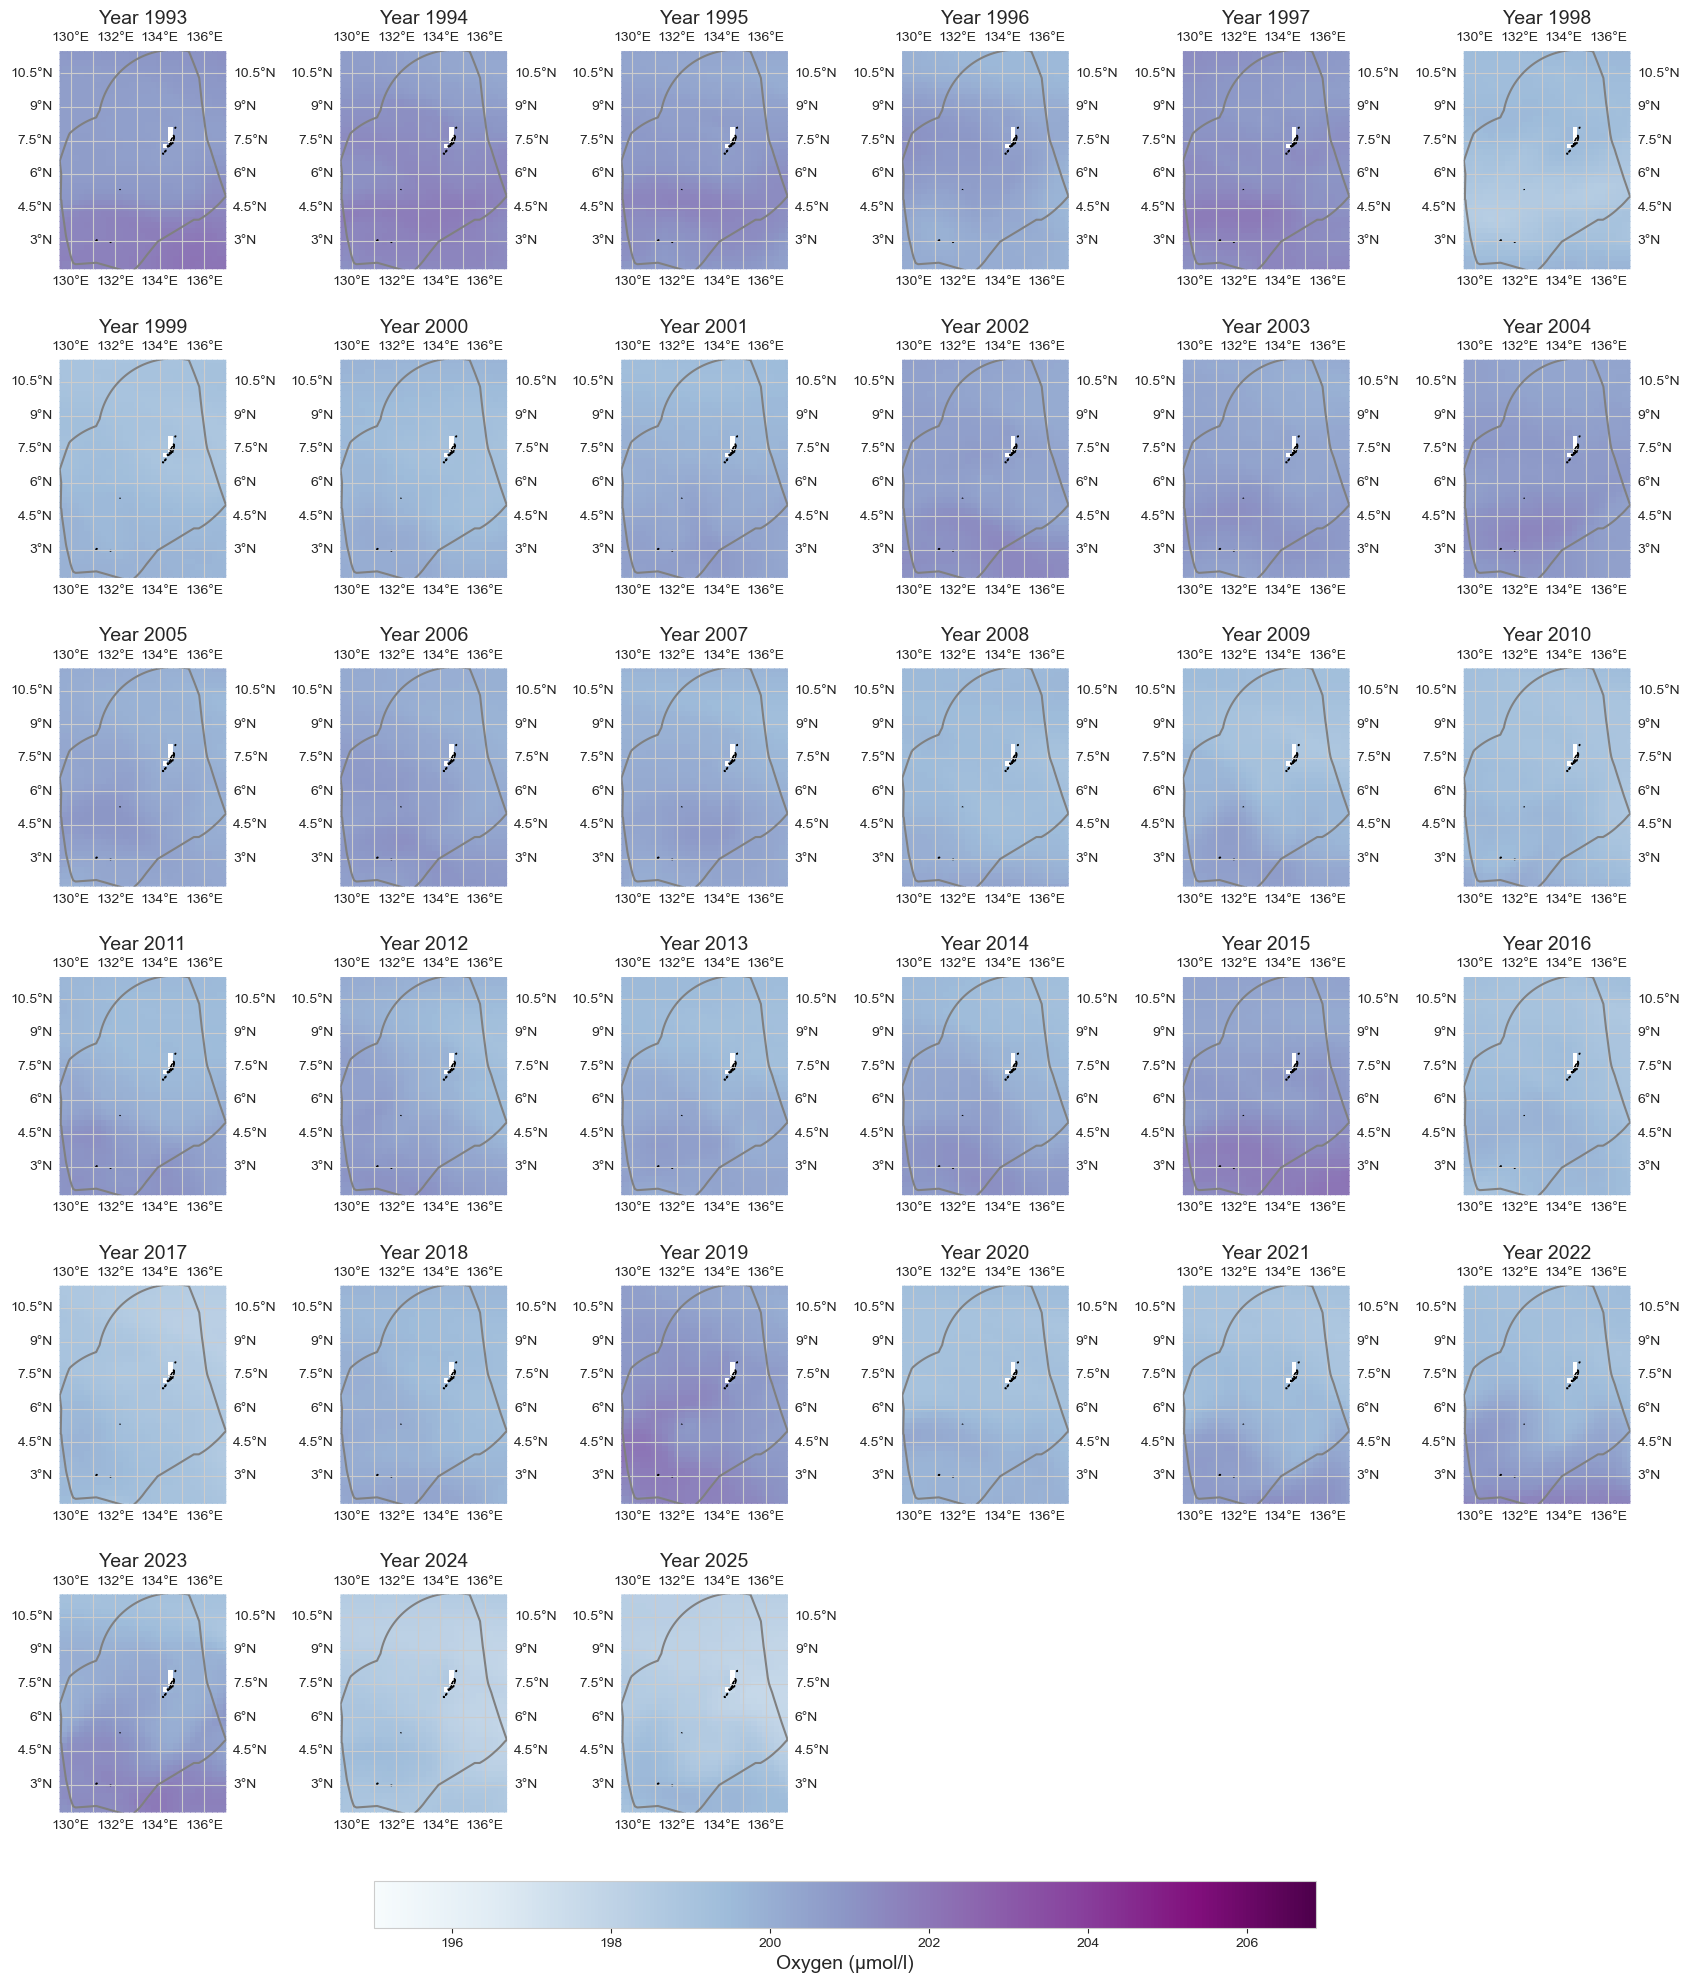

In [10]:
data_y = data_xr.resample(time='1YE').mean()
im = plot_map_subplots(data_y, dataset_id, shp_eez = shp_eez, cmap = 'BuPu', 
                  vmin = np.nanpercentile(data_xr.min(dim = 'time')[dataset_id], 1), 
                  vmax = np.nanpercentile(data_xr.max(dim = 'time')[dataset_id], 99),
                  cbar = 1)

#### Annual anomaly

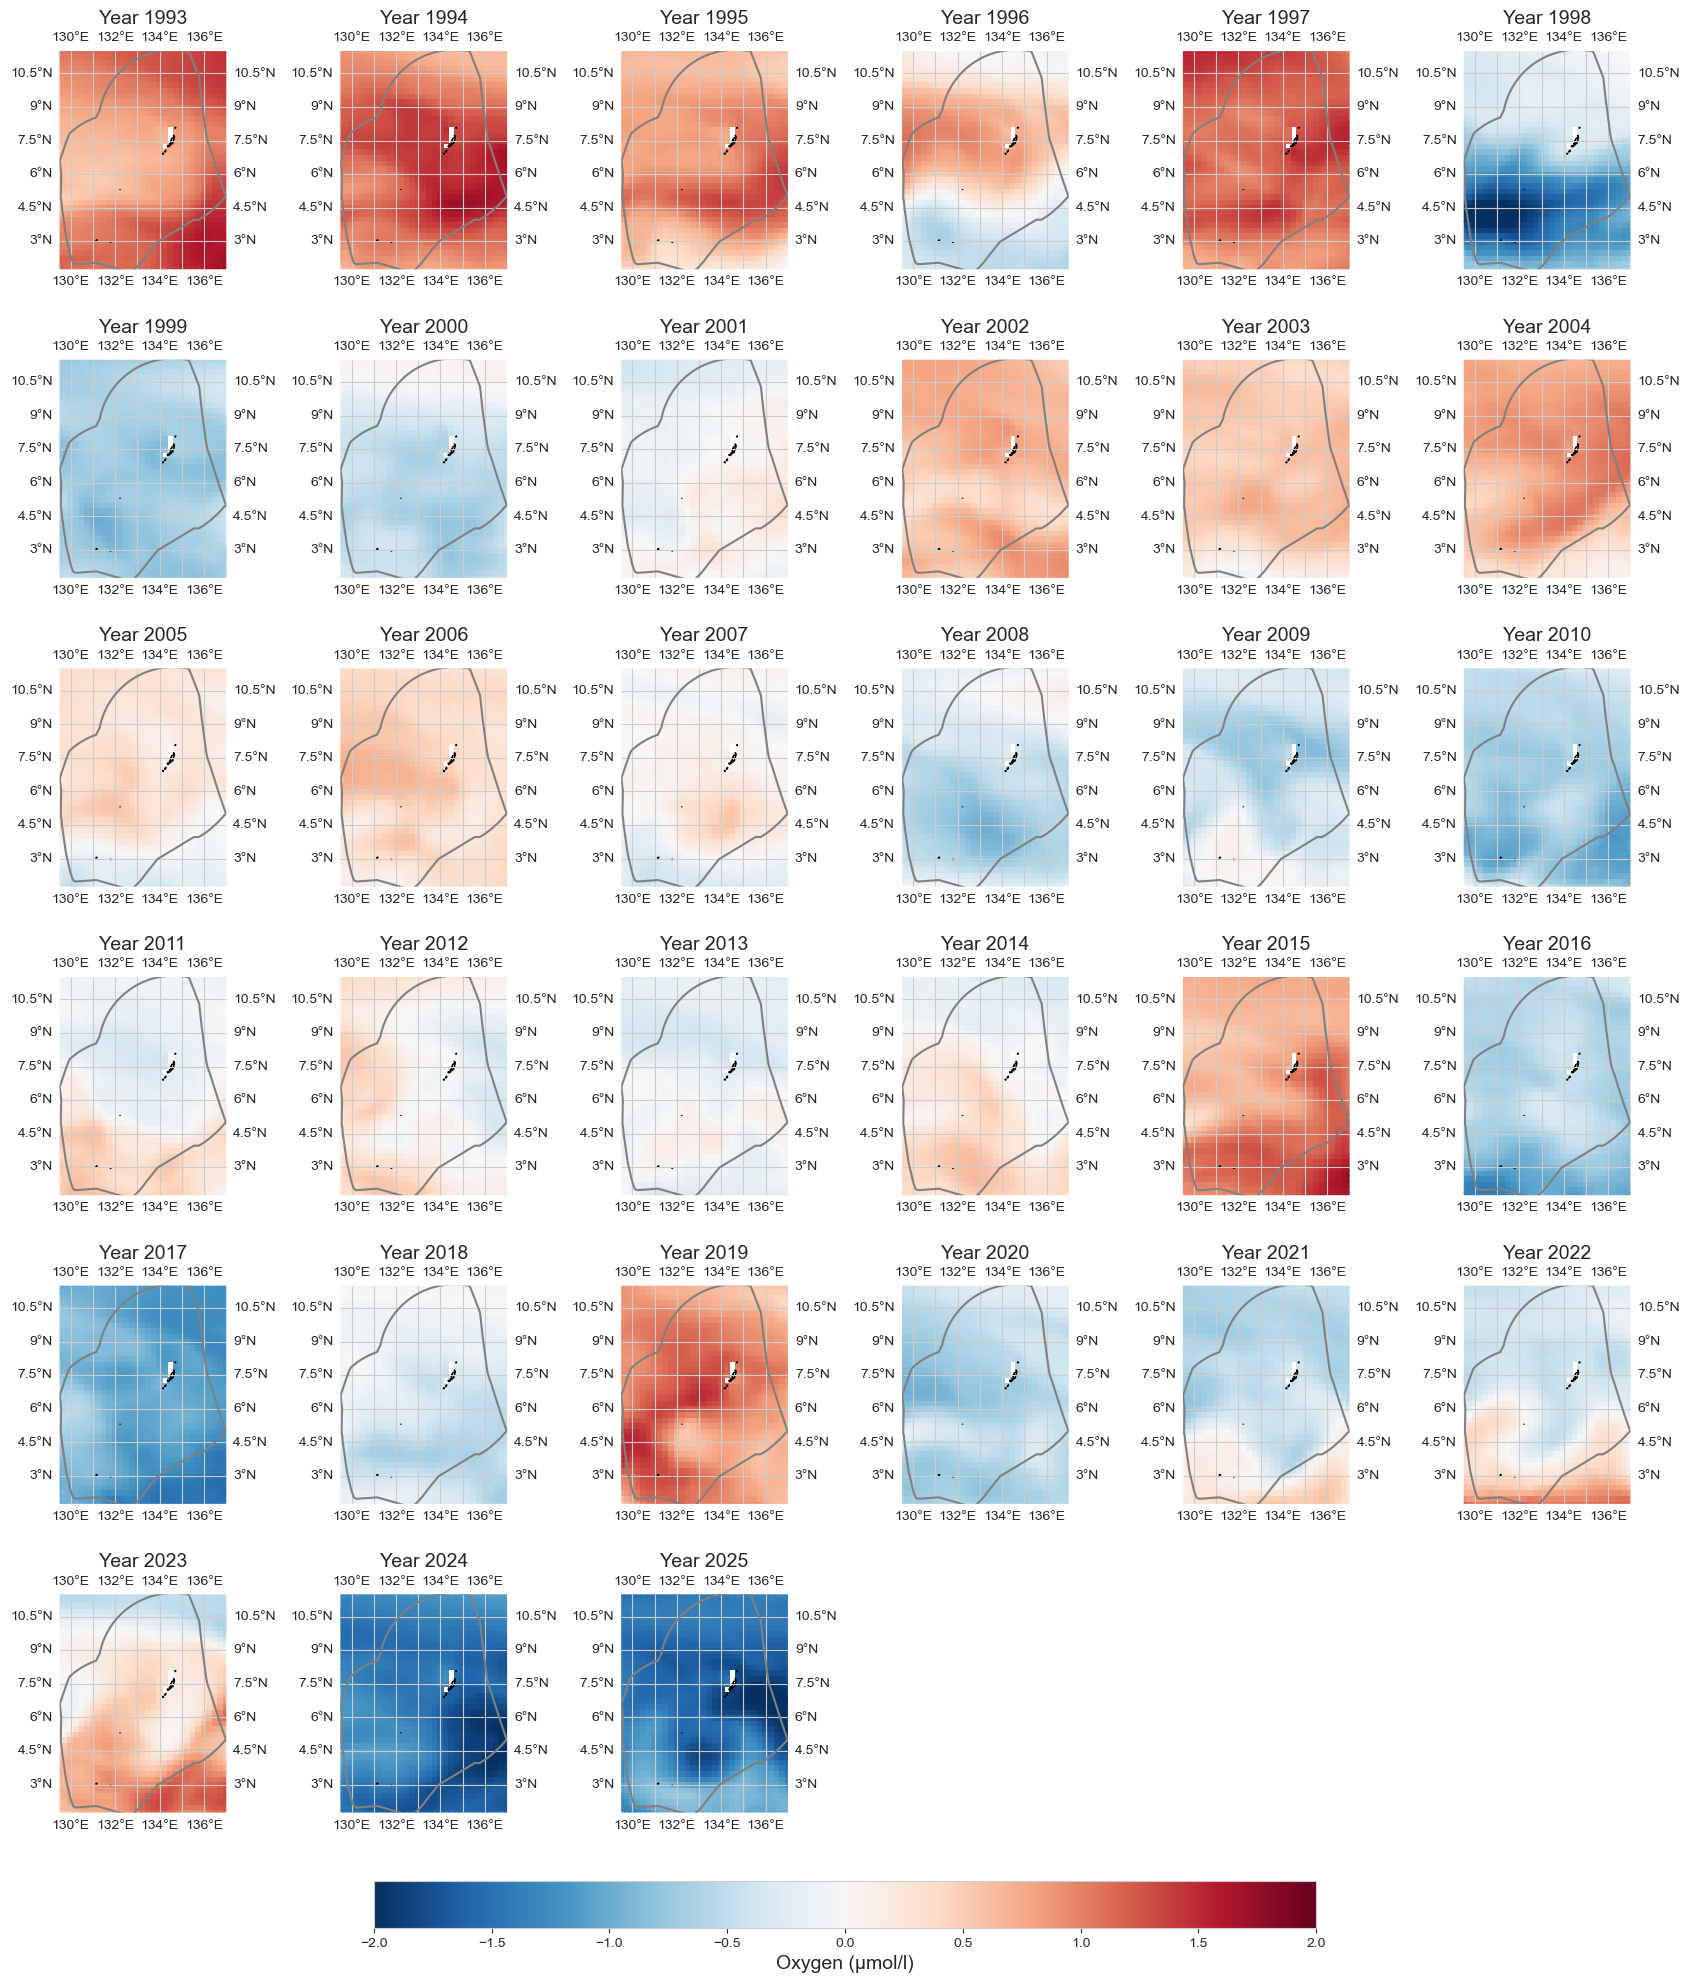

In [11]:
data_an = data_y - data_xr.mean(dim='time')
fig = plot_map_subplots(data_an, dataset_id, shp_eez = shp_eez, cmap='RdBu_r', vmin=-2, vmax=2, cbar = 1)

#### Average over area

In [12]:
dict_plot = [{'data' : data_xr.mean(dim = ['longitude', 'latitude']).to_dataframe(), 
              'var' : dataset_id, 'ax' : 1, 'label' : f'{label} - MEAN AREA'},]

In [13]:
fig, trend = plot_timeseries_interactive(dict_plot, trendline=True, return_trend=True, scatter_dict = None, figsize = (25, 12), label_yaxes = label);
fig.write_html(op.join(path_figs, 'F17_O2_mean_trend.html'), include_plotlyjs="cdn")


#### Seasonal variability

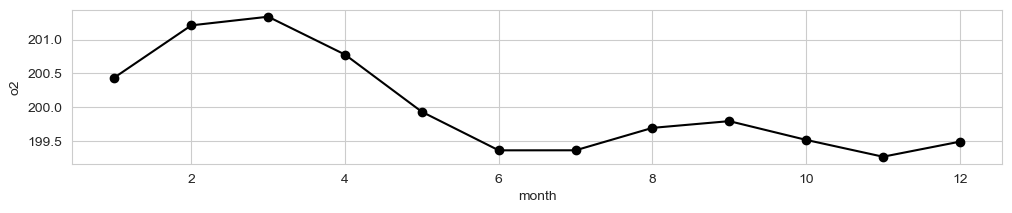

In [14]:
fig, ax = plt.subplots(figsize=(12,2))
data_xr.mean(dim = ['longitude', 'latitude']).groupby('time.month').mean()[dataset_id].plot(ax = ax, marker = 'o', color = 'k')

#### Timeseries at a given point

In [15]:
loc = [7.37, 134.7]
dict_plot = [{'data' : data_xr.sel(longitude=loc[1], latitude=loc[0], method='nearest').to_dataframe(), 
              'var' : dataset_id, 'ax' : 1, 'label' : f'{label} at [{loc[0]}, {loc[1]}]'},]

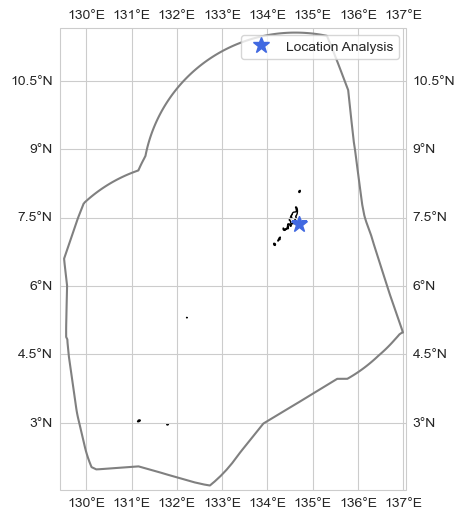

In [16]:
fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
ax.plot(loc[1], loc[0], '*', markersize = 12, color = 'royalblue', transform=ccrs.PlateCarree(), label = 'Location Analysis')
ax.legend()

In [17]:
fig = plot_timeseries_interactive(dict_plot, trendline=True, scatter_dict = None, figsize = (25, 12), label_yaxes = label);

### ONI index analysis

In [18]:
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
df1 = download_oni_index(p_data)

In [19]:
lims = [-.5, .5]
plot_oni_index_th(df1, lims = lims)

Group by ONI category

In [20]:
df1 = add_oni_cat(df1, lims = lims)
df1['ONI'] = df1['oni_cat']
data_xr['ONI'] = (('time'), df1.iloc[np.intersect1d(data_xr.time, df1.index, return_indices=True)[2]].ONI.values)
data_xr['ONI_cat'] = (('time'), np.where(data_xr.ONI < lims[0], -1, np.where(data_xr.ONI > lims[1], 1, 0)))
data_oni = data_xr.groupby('ONI_cat').mean()

#### Average

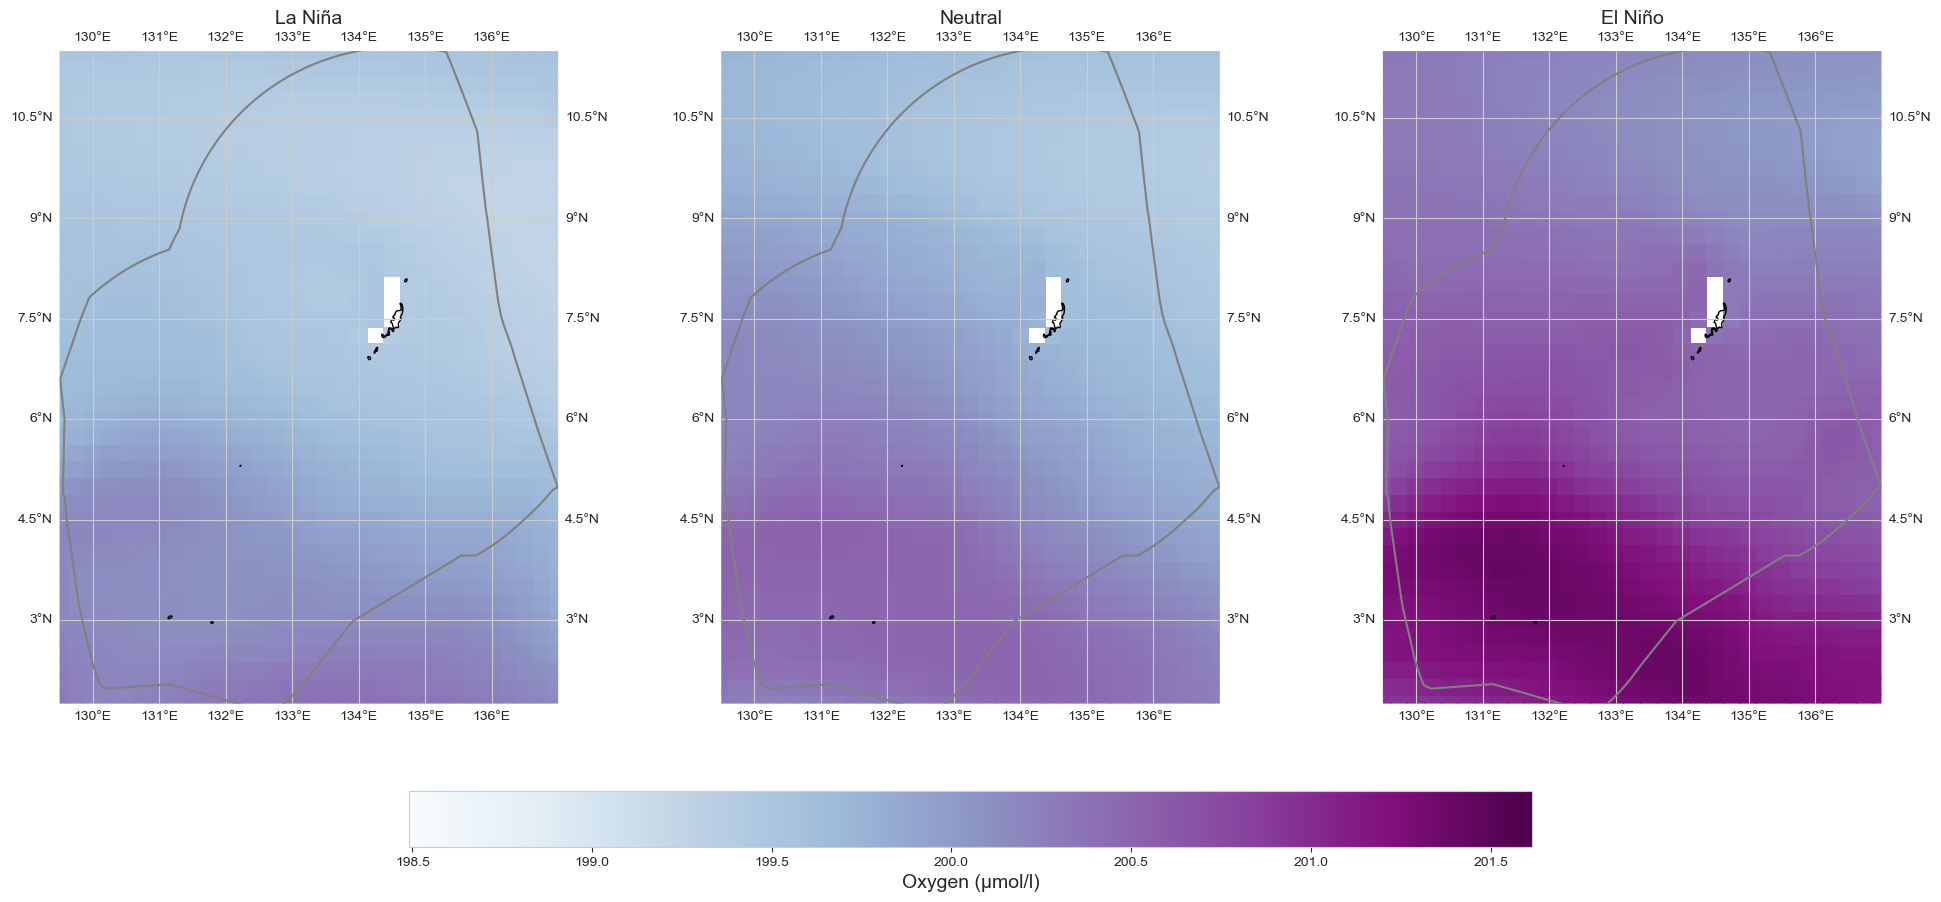

In [21]:
fig = plot_map_subplots(data_oni, dataset_id, shp_eez = shp_eez, cmap = 'BuPu', 
                  vmin = np.nanpercentile(data_xr.mean(dim = 'time')[dataset_id], 1) - 1, 
                  vmax = np.nanpercentile(data_xr.mean(dim = 'time')[dataset_id], 99) + 1,
                  sub_plot= [1, 3], figsize = (20, 9),  cbar = True, cbar_pad = 0.1,
                  titles = ['La Niña', 'Neutral', 'El Niño'],)
plt.savefig(op.join(path_figs, 'F17_O2_ENSO.png'), dpi=300, bbox_inches='tight')


#### Anomaly

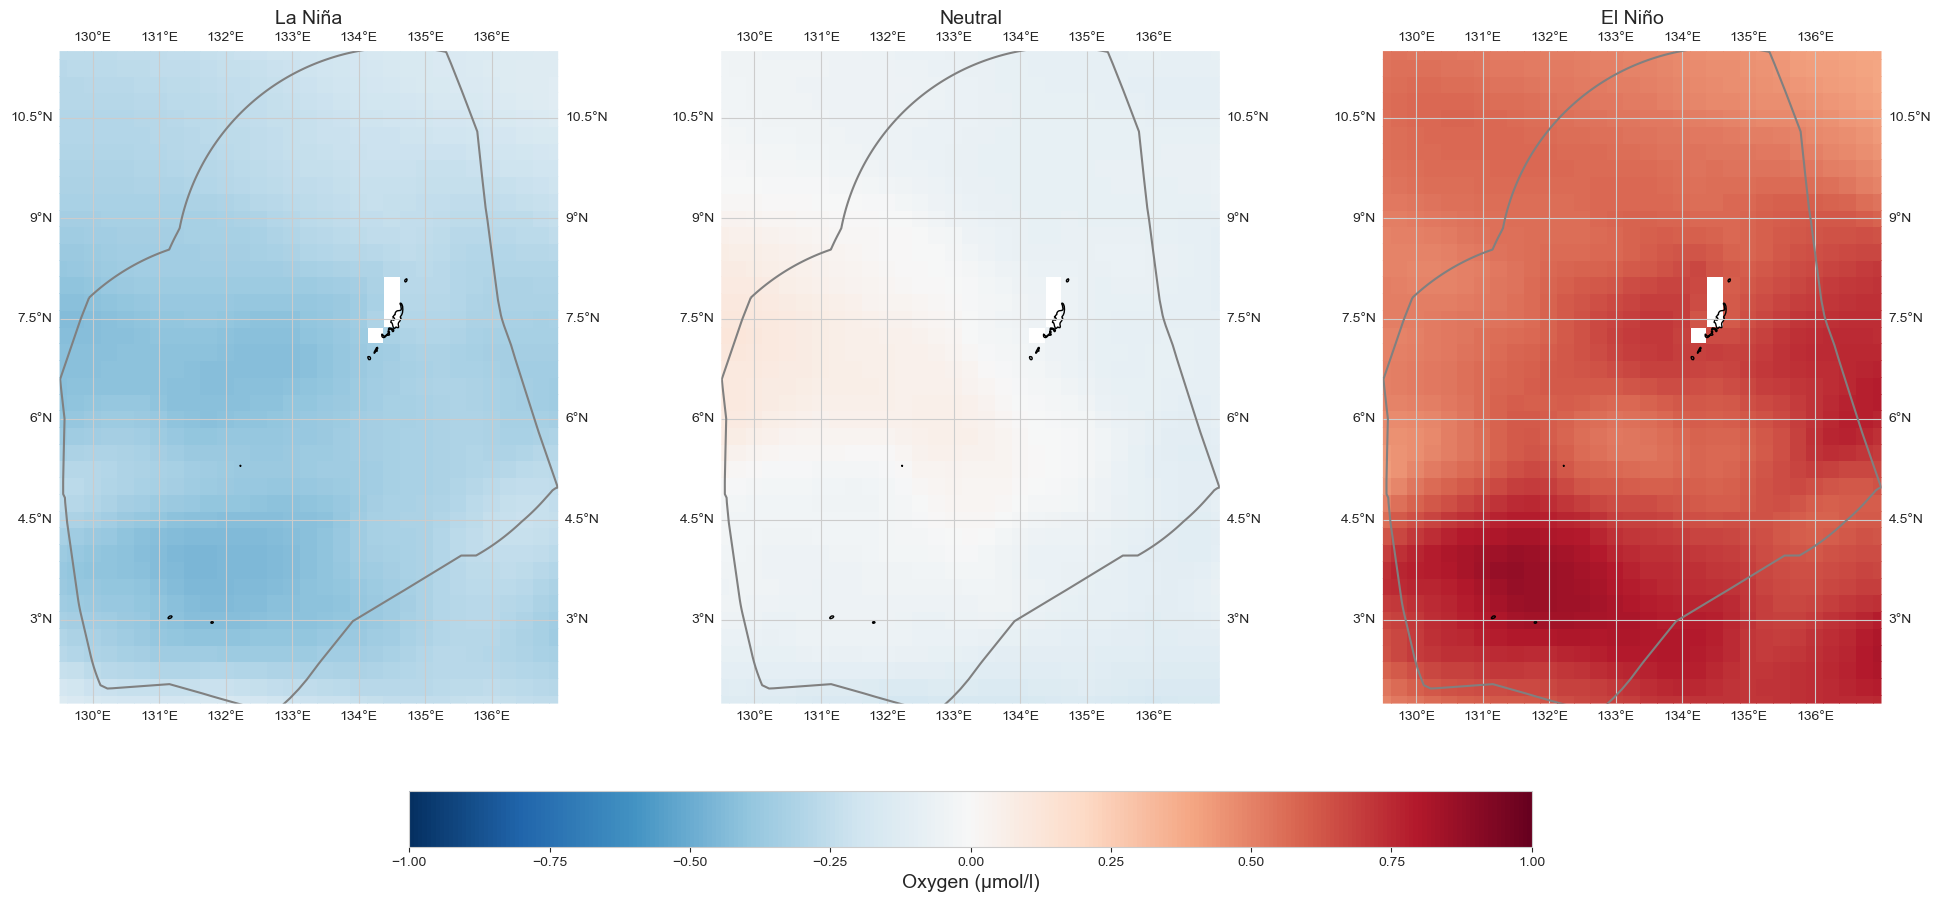

In [22]:
data_an = data_oni - data_xr.mean(dim='time')
fig = plot_map_subplots(data_an, dataset_id, shp_eez = shp_eez, cmap='RdBu_r', vmin=-1, vmax=1,
                  sub_plot= [1, 3], figsize = (20, 9),  cbar = True, cbar_pad = 0.1,
                  titles = ['La Niña', 'Neutral', 'El Niño'],)

## Table

In [24]:
from ind_setup.tables import style_matrix, table_ocean
style_matrix(table_ocean(data_xr, trend[0], data_oni, dataset_id))

Metric,Value
Monthly Average,200.018
Monthly Maximum 01/02/2019,203.530
Monthly Minimum 01/11/1998,196.795
Maximum Annual Average,201.180
Minimum Annual Average,198.524
Rate of change [µmol/l/year],-0.037
Change between 1993 and 2025 [µmol/l],-1.184
,
Average La Niña o2,199.705
Average El Niño o2,200.643
